In [106]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
import numpy as np
import copy
from collections import defaultdict, deque
import pickle
import random
from tqdm import trange
import matplotlib.pyplot as plt

In [107]:
Operator = Optional[str]  # '+', '-', 'x', '/' or None

@dataclass
class Piece:
    player: int  # 1 = Blue, -1 = Red
    value: int
    dama: bool = False

    def __repr__(self):
        # Convert B to blue emoji and R to red emoji for better visualization
        p = "🔵" if self.player == 1 else "🔴"
        val = f"{self.value:+d}" if self.value >= 0 else str(self.value)
        return f"{p}{'D' if self.dama else ''}{val}"
    
    
    def copy(self):
        return Piece(self.player, self.value, self.dama)

@dataclass
class Move:
    path: List[Tuple[int, int]]            # sequence of positions traversed
    captures: List[Tuple[int, int]]        # list of captured piece positions
    promotes: bool = False                 # whether the move results in promotion
    score_gain: int = 0                    # arithmetic reward from the move
    is_dama_capture: bool = False          # whether move made by dama
    is_multi_jump: bool = False            # whether multiple captures occurred

    def __repr__(self):
        cap_str = f" x{len(self.captures)}" if self.captures else ""
        promo = " (promo)" if self.promotes else ""
        return f"{self.path}{cap_str}{promo} +{self.score_gain}"



In [108]:
class DamathEnv:
    def __init__(self, rows=8, cols=8, operator_pattern=None):
        self.R = rows
        self.C = cols
        assert rows==8 and cols==8, "Currently implemented for 8x8 boards."
        # Operators on playable squares. Default pattern similar to provided image if None.
        if operator_pattern is None:
            operator_pattern = self.default_operator_board()
        self.op_board = operator_pattern
        # Piece board: dict (r,c)->Piece
        self.pieces: Dict[Tuple[int,int], Piece] = {}
        # Scores cumulative per player
        self.scores = {1: 0.0, -1: 0.0}
        self.to_move = 1  # 1 starts (blue on top)
        self.history_states = deque(maxlen=50)  # for repetition detection (store simple board hashes)
        
        # initialize sample starting board if user wants. We'll provide a helper to set initial config.
        self.init_default_integer_setup()

    def default_operator_board(self):
        # Create operator layout (8x8) using a repeating pattern similar to the uploaded assets.
        # Operators placed on playable squares (r+c)%2==1.
        ops = ['x','/','-','+']  # cycle
        board = [[None for _ in range(self.C)] for __ in range(self.R)]
        for r in range(self.R):
            for c in range(self.C):
                if (r + c) % 2 == 1:
                    # choose operator based on some pattern; rotate every cell
                    board[r][c] = ops[(r + 2*c) % len(ops)]
                else:
                    board[r][c] = None
        return board

    def init_default_integer_setup(self):
        # Initialize pieces according to the "integer damath" sample. We'll follow a symmetric-ish layout.
        # Blue (player=1) on top three rows playable squares, Red (player=-1) on bottom three rows.
        self.pieces = {}
        # sample integer values, you can customize to exact image mapping
        blue_values = [
            [-11, 8, -5, 2],
            [0, -3, 10, -7],
            [-9, 6, -1, 4],
        ]
        red_values = [
            [4, -1, 6, -9],
            [-7, 10, -3, 0],
            [2, -5, 8, -11]
        ]
        # place on playable squares; for top rows choose columns 0,2,4,6 for row 0,1.. pattern.
        # We'll place blues on rows 0..2 and reds on rows 5..7 so that they face each other.
        # map values left to right
        def playable_positions_on_row(r):
            # playable cols where (r+c)%2==1
            return [c for c in range(self.C) if (r+c)%2==1]
        # Blue top 3 rows
        for i, r in enumerate(range(0,3)):
            cols = playable_positions_on_row(r)
            vals = blue_values[i]
            for j, c in enumerate(cols[:len(vals)]):
                self.pieces[(r,c)] = Piece(player=1, value=vals[j], dama=False)
        # Red bottom 3 rows
        for i, r in enumerate(range(5,8)):
            cols = playable_positions_on_row(r)
            vals = red_values[i-0] if i < len(red_values) else []
            for j, c in enumerate(cols[:len(vals)]):
                self.pieces[(r,c)] = Piece(player=-1, value=vals[j], dama=False)
        # reset scores and to_move
        self.scores = {1:0.0, -1:0.0}
        self.to_move = 1
        self.history_states.clear()
        self.record_state()

    def copy(self):
        newenv = DamathEnv(self.R, self.C)
        newenv.op_board = copy.deepcopy(self.op_board)
        newenv.pieces = {k: v.copy() for k,v in self.pieces.items()}
        newenv.scores = dict(self.scores)
        newenv.to_move = self.to_move
        newenv.history_states = copy.deepcopy(self.history_states)
        return newenv

    def in_bounds(self, r,c):
        return 0 <= r < self.R and 0 <= c < self.C

    def is_playable(self, r,c):
        return self.in_bounds(r,c) and ((r+c)%2==1)

    def get_piece(self, r,c) -> Optional[Piece]:
        return self.pieces.get((r,c))

    def remove_piece(self, r,c):
        if (r,c) in self.pieces:
            del self.pieces[(r,c)]

    def move_piece(self, from_rc, to_rc):
        p = self.pieces.pop(from_rc)
        self.pieces[to_rc] = p
        return p

    def record_state(self):
        # Simple hash of pieces positions and values and to_move for repetition detection
        items = tuple(sorted([ (pos, piece.player, piece.value, piece.dama) for pos,piece in self.pieces.items() ]))
        key = (self.to_move, items)
        self.history_states.append(key)

    # ----------------------------- Operators & arithmetic -----------------------------
    def op_at(self, r,c):
        if not self.is_playable(r,c):
            return None
        return self.op_board[r][c]

    def apply_operator(self, op: str, a: int, b: int):
        if op == '+':
            return a + b
        if op == '-':
            return a - b
        if op == 'x' or op == 'X' or op == '*':
            return a * b
        if op == '/':
            # integer division semantics: handle division by zero and prefer integer division rounding toward zero
            if b == 0:
                # define a penalty or large negative? For now, return 0 to avoid crash.
                return 0
            return int(a / b)
        raise ValueError("Unknown op "+str(op))

    # ----------------------------- Movement and capture generation -----------------------------
    def generate_all_moves(self, player:int):
        """
        Returns a list of Move objects representing all legal moves for player.
        Enforces mandatory captures and priority rules described in prompt.
        """
        # 1) Find all capture sequences for every piece
        capture_moves = []
        for pos, piece in list(self.pieces.items()):
            if piece.player != player: continue
            caps = self._generate_captures_from(pos, piece)
            capture_moves.extend(caps)
        if len(capture_moves) > 0:
            # enforce capture priority: (1) max captures, (2) if tie, dama priority, (3) if regular has more captures than dama, regular wins
            max_cap = max(len(m.captures) for m in capture_moves)
            # filter moves with max captures
            maxcap_moves = [m for m in capture_moves if len(m.captures)==max_cap]
            # among tied moves, if any are from dama pieces and any from regular, prefer dama (unless regular has strictly more captures in other moves)
            # but since we already filtered to max_cap, only need to prefer dama among ties => prefer moves with piece.dama True if any
            if any(self.pieces[m.path[0]].dama for m in maxcap_moves): # note m.path[0] original square
                maxcap_moves = [m for m in maxcap_moves if self.pieces[m.path[0]].dama]
            # compute score_gain for each move using current op board and multipliers
            for m in maxcap_moves:
                m.score_gain = self._compute_move_score(m, player)
            return maxcap_moves
        # 2) If no captures, generate simple moves including dama moves
        simple_moves = []
        for pos, piece in list(self.pieces.items()):
            if piece.player != player: continue
            sms = self._generate_simple_from(pos, piece)
            simple_moves.extend(sms)
        # mark score_gain zero for these
        for m in simple_moves:
            m.score_gain = 0.0
        return simple_moves

    def _generate_simple_from(self, pos, piece:Piece):
        r,c = pos
        moves = []
        if piece.dama:
            # dama can move any distance along diagonals (like king in international draughts)
            for dr,dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
                step=1
                while True:
                    nr = r + dr*step; nc = c + dc*step
                    if not self.in_bounds(nr,nc) or not self.is_playable(nr,nc): break
                    if (nr,nc) in self.pieces: break
                    path = [(r,c),(nr,nc)]
                    promotes = self._check_promotion(nr, piece.player)
                    moves.append(Move(path=path, captures=[], promotes=promotes))
                    step += 1
        else:
            # regular piece: forward-only? In Damath, regular pieces can move diagonally forward one space.
            # We assume player=1 moves 'down' (increasing row), player=-1 moves 'up' (decreasing row).
            dr = 1 if piece.player==1 else -1
            for dc in (-1,1):
                nr = r + dr; nc = c + dc
                if not self.in_bounds(nr,nc) or not self.is_playable(nr,nc): continue
                if (nr,nc) in self.pieces: continue
                path=[(r,c),(nr,nc)]
                promotes = self._check_promotion(nr, piece.player)
                moves.append(Move(path=path, captures=[], promotes=promotes))
        return moves

    def _generate_captures_from(self, pos, piece:Piece):
        # returns all capture sequences starting from this piece (as Move objects)
        # For regular pieces: jump over adjacent opponent piece landing on square beyond if empty; can chain.
        # For dama pieces: long-range capture along diagonals: can jump over an opponent piece that has at least one empty landing square beyond it on the same diagonal. Dama can land on any empty square beyond the captured piece on that diagonal (but rules about priority when multiple captures available are handled globally).
        results = []
        r,c = pos

        if piece.dama:
            # long-range captures: for each diagonal, find opponent pieces and possible landing squares beyond.
            for dr,dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
                # step along diagonal to find first opponent piece(s)
                step=1
                while True:
                    mr = r + dr*step; mc = c + dc*step
                    if not self.in_bounds(mr,mc) or not self.is_playable(mr,mc): break
                    if (mr,mc) in self.pieces:
                        target = self.pieces[(mr,mc)]
                        if target.player == piece.player:
                            break  # blocked by own piece
                        # find landing squares beyond (must be empty)
                        land_step = 1
                        while True:
                            lr = mr + dr*land_step; lc = mc + dc*land_step
                            if not self.in_bounds(lr,lc) or not self.is_playable(lr,lc): break
                            if (lr,lc) in self.pieces: break
                            # found a possible landing square
                            # create a tentative move: capture that one piece and land on (lr,lc)
                            new_env = self.copy()
                            # perform capture on new_env to continue searching for multi-captures
                            captured_piece = new_env.pieces.pop((mr,mc))
                            moved_piece = new_env.pieces.pop((r,c))
                            new_env.pieces[(lr,lc)] = moved_piece
                            # Recurse to find further captures from (lr,lc)
                            # Note: we store the captured piece object snapshot as part of capture tuple
                            further = new_env._generate_captures_from((lr,lc), moved_piece)
                            if len(further)==0:
                                m = Move(path=[(r,c),(lr,lc)], captures=[(mr,mc,captured_piece)], promotes=False)
                                results.append(m)
                            else:
                                for fm in further:
                                    # prepend current capture to fm
                                    m = Move(path=[(r,c)] + fm.path, captures=[(mr,mc,captured_piece)] + fm.captures, promotes=False)
                                    results.append(m)
                            land_step += 1
                        break  # only consider the first opponent piece along diagonal for long-range capture
                    else:
                        step += 1

        else:
            # regular piece captures: check adjacent diagonals for opponent piece and landing square beyond
            for dr,dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
                ar = r + dr; ac = c + dc  # adjacent
                lr = r + 2*dr; lc = c + 2*dc  # landing beyond
                if not self.in_bounds(ar,ac) or not self.is_playable(ar,ac): continue
                if (ar,ac) not in self.pieces: continue
                if self.pieces[(ar,ac)].player == piece.player: continue
                if not self.in_bounds(lr,lc) or not self.is_playable(lr,lc): continue
                if (lr,lc) in self.pieces: continue
                # simulate capture and recurse
                new_env = self.copy()
                captured_piece = new_env.pieces.pop((ar,ac))
                moved_piece = new_env.pieces.pop((r,c))
                new_env.pieces[(lr,lc)] = moved_piece
                further = new_env._generate_captures_from((lr,lc), moved_piece)
                if len(further)==0:
                    m = Move(path=[(r,c),(lr,lc)], captures=[(ar,ac,captured_piece)], promotes=self._check_promotion(lr,piece.player))
                    results.append(m)
                else:
                    for fm in further:
                        m = Move(path=[(r,c)] + fm.path, captures=[(ar,ac,captured_piece)] + fm.captures, promotes=self._check_promotion(fm.path[-1][0], piece.player))
                        results.append(m)
        # remove duplicate sequences (same path) - dedupe by path and captured coordinates
        uniq = {}
        for m in results:
            key = (tuple(m.path), tuple((r,c,cp.value) for r,c,cp in m.captures))
            if key not in uniq or len(uniq[key].captures) < len(m.captures):
                uniq[key] = m
        return list(uniq.values())

    def _compute_move_score(self, move:Move, mover_player:int):
        # compute arithmetic score gain to mover for a capture move following rules:
        # - each captured piece adds op(own_value, captured_value) where op is operator on the landing square of that jump
        # - for dama captures, double score; if both dama, quadruple for that take.
        # - if a dama is taken by regular, the score is doubled as well (we handle multiplier on capture event)
        total = 0.0
        # need to reconstruct the piece value used in each jump: the moving piece's value at that time can be assumed unchanged
        # We'll use the mover's piece's original value
        # For multi-jumps, landing squares determine operators used
        mover_start = move.path[0]
        mover_piece = self.pieces.get(mover_start)
        mover_is_dama = mover_piece.dama if mover_piece else False
        # We must approximate the moving piece's value; in rules it's the mover's own piece value each time
        mover_value = mover_piece.value if mover_piece else 0
        # For each capture in sequence, determine operator at landing square (the square after the specific jump)
        # To find landing square for ith capture: it's path[1+i]
        for i, (cap_r,cap_c,cap_piece) in enumerate(move.captures):
            landing = move.path[1+i] if len(move.path) > 1+i else move.path[-1]
            op = self.op_at(*landing)
            # apply operator: op(self_value, captured_value)
            base = self.apply_operator(op, mover_value, cap_piece.value)
            # multipliers:
            mult = 1
            # If mover is dama, double for that take; if captured is dama and mover is dama -> quadruple (2*2)
            if mover_is_dama and cap_piece.dama:
                mult = 4
            elif mover_is_dama:
                mult = 2
            elif cap_piece.dama:
                # captured is dama and mover is regular: score doubled as well per rules
                mult = 2
            total += base * mult
        return total

    def _check_promotion(self, r, player):
        # If a piece reaches opposing end (row 7 for player=1, row 0 for player=-1), it is promoted
        if player==1 and r==self.R-1: return True
        if player==-1 and r==0: return True
        return False

    # ----------------------------- Apply Move -----------------------------
    def apply_move(self, move: "Move", verbose=False):
        """
        Apply a move and update board state + cumulative self.scores.
        Immediate reward is disabled — returns 0.0 every call.
        """
        player = self.to_move

        if len(move.captures) == 0:
            frm, to = move.path[0], move.path[-1]
            piece = self.pieces.pop(frm)
            self.pieces[to] = piece

            if self._check_promotion(to[0], piece.player) and not piece.dama:
                piece.dama = True

        else:
            frm = move.path[0]
            mover = self.pieces.pop(frm)
            current_pos = frm
            total_gain = 0.0

            for i, (cap_r, cap_c, cap_piece_snapshot) in enumerate(move.captures):
                landing = move.path[1 + i] if 1 + i < len(move.path) else move.path[-1]
                op = self.op_at(*landing)
                captured_piece = self.pieces.pop((cap_r, cap_c))
                base = self.apply_operator(op, mover.value, captured_piece.value)

                mult = 1
                if mover.dama and captured_piece.dama:
                    mult = 4
                elif mover.dama or captured_piece.dama:
                    mult = 2

                total_gain += base * mult
                current_pos = landing

            self.pieces[current_pos] = mover
            if self._check_promotion(current_pos[0], mover.player) and not mover.dama:
                mover.dama = True
            self.scores[mover.player] += total_gain

        self.to_move *= -1
        self.record_state()

        if verbose:
            print(f"[Player {player}] applied move, scores={self.scores}")
        return 0.0
        
            # ----------------------------- Terminal Reward -----------------------------
    def compute_final_reward_for(self, player: int = 1, reward_alpha: float = 0.7, K: float = 100.0):
        """
        Compute final combined reward for `player`:
            final_reward = α * binary_outcome + (1 - α) * tanh((score_diff)/K)
        Returns (final_reward, winner, final_scores)
        """
        final_scores, winner = self.final_scores_and_winner()
        p_score = final_scores.get(player, 0.0)
        o_score = final_scores.get(-player, 0.0)

        # Binary component
        if winner == player:
            binary_reward = 1.0
        elif winner == -player:
            binary_reward = -1.0
        else:
            binary_reward = 0.0

        # Normalized score difference
        norm_diff = float(np.tanh((p_score - o_score) / K))
        final_reward = float(reward_alpha * binary_reward + (1 - reward_alpha) * norm_diff)
        final_reward = float(np.clip(final_reward, -1.0, 1.0))
        return final_reward, winner, final_scores


    # ----------------------------- Game end and scoring -----------------------------
    def legal_moves_exist(self, player:int):
        return len(self.generate_all_moves(player))>0

    def game_over(self):
        # game over if current player to move has no moves or only one player's chips remain or repetition or stalemate
        if not self.legal_moves_exist(self.to_move):
            return True
        # if only chips of one player remain
        players_present = set(p.player for p in self.pieces.values())
        if len(players_present) <= 1:
            return True
        # repetition detection (simple): if last 6 states repeated pattern
        # For now, consider repetition if history has same state repeated >=4 times overall
        hist = list(self.history_states)
        if len(hist) >= 8:
            counts = defaultdict(int)
            for h in hist:
                counts[h] += 1
                if counts[h] >= 4:
                    return True
        return False

    def final_scores_and_winner(self):
        # Add remaining pieces to their player's cumulative scores (dama doubled)
        final_scores = dict(self.scores)
        for (r,c), piece in self.pieces.items():
            val = piece.value * (2 if piece.dama else 1)
            final_scores[piece.player] += val
        # Determine winner
        if final_scores[1] > final_scores[-1]:
            winner = 1
        elif final_scores[1] < final_scores[-1]:
            winner = -1
        else:
            winner = 0
        return final_scores, winner

    # ----------------------------- Utilities -----------------------------
    def print_board(self):
        # Create board grid with operators and pieces
        grid = [[" ." for _ in range(self.C)] for __ in range(self.R)]
        for y in range(self.R):
            for x in range(self.C):
                if not self.is_playable(y, x):
                    grid[y][x] = "##"
                else:
                    op = self.op_at(y, x)
                    grid[y][x] = f" {op}"
        # Place pieces
        for (y, x), piece in self.pieces.items():
            sym = '🔵' if piece.player == 1 else '🔴'
            if piece.dama:
                sym += 'K'
            grid[y][x] = f"{sym}{piece.value:02d}" if piece.value >= 0 else f"{sym}{piece.value}"

        # Print column headers
        print("\n     " + " ".join([f"{x:>4}" for x in range(self.C)]))
        print("     " + "----" * self.C)

        # Print from top (highest y) to bottom (y=0)
        for y in reversed(range(self.R)):
            row_str = " ".join(f"{cell:>4}" for cell in grid[y])
            print(f"{y:>2} | {row_str} | {y:>2}")

        print("     " + "----" * self.C)
        print("     " + " ".join([f"{x:>4}" for x in range(self.C)]))
        
    def get_state_hash(self):
        items = tuple(sorted([(pos, p.player, p.value, p.dama) 
                        for pos, p in self.pieces.items()]))
        return (self.to_move, items)


In [109]:
# Operator layout: (y, x) format
# y=0 is bottom row, y=7 is top row

operator_pattern_official = [
    ['x', '-', '/', 'x', '-', '+', '+', 'x'],
    ['-', '/', '-', 'x', '-', '+', 'x', '-'],
    ['-', '+', '+', '+', 'x', 'x', '/', '+'],
    ['x', '+', '+', '-', 'x', '/', '+', 'x'],
    ['x', '-', '/', 'x', '-', '-', '+', 'x'],
    ['-', '/', 'x', 'x', '-', '+', 'x', '-'],
    ['-', 'x', '+', '+', 'x', 'x', '/', '+'],
    ['+', '/', '-', '-', 'x', '/', '+', 'x']
]

env = DamathEnv(rows = 8, cols = 8, operator_pattern=operator_pattern_official)
env.print_board()
moves = env.generate_all_moves(env.to_move)
print("\nAvailable moves for player", env.to_move, "->", len(moves))
for move in moves:
    start = move.path[0]
    end = move.path[-1]
    piece = env.pieces.get(start, None)
    if piece:
        piece_type = "Dama" if piece.dama else "Regular"
        # Swap (y, x) to (x, y) for readability
        print(f"{piece_type} {piece.value:+d} at ({start[1]}, {start[0]}) -> ({end[1]}, {end[0]}) | ΔScore: {move.score_gain:+.1f}")
    else:
        print(f"Unknown piece at ({start[1]}, {start[0]}) -> ({end[1]}, {end[0]}) | ΔScore: {move.score_gain:+.1f}")




        0    1    2    3    4    5    6    7
     --------------------------------
 7 |  🔴02   ##  🔴-5   ##  🔴08   ## 🔴-11   ## |  7
 6 |   ##  🔴-7   ##  🔴10   ##  🔴-3   ##  🔴00 |  6
 5 |  🔴04   ##  🔴-1   ##  🔴06   ##  🔴-9   ## |  5
 4 |   ##    -   ##    x   ##    -   ##    x |  4
 3 |    x   ##    +   ##    x   ##    +   ## |  3
 2 |   ##  🔵-9   ##  🔵06   ##  🔵-1   ##  🔵04 |  2
 1 |  🔵00   ##  🔵-3   ##  🔵10   ##  🔵-7   ## |  1
 0 |   ## 🔵-11   ##  🔵08   ##  🔵-5   ##  🔵02 |  0
     --------------------------------
        0    1    2    3    4    5    6    7

Available moves for player 1 -> 7
Regular -9 at (1, 2) -> (0, 3) | ΔScore: +0.0
Regular -9 at (1, 2) -> (2, 3) | ΔScore: +0.0
Regular +6 at (3, 2) -> (2, 3) | ΔScore: +0.0
Regular +6 at (3, 2) -> (4, 3) | ΔScore: +0.0
Regular -1 at (5, 2) -> (4, 3) | ΔScore: +0.0
Regular -1 at (5, 2) -> (6, 3) | ΔScore: +0.0
Regular +4 at (7, 2) -> (6, 3) | ΔScore: +0.0


In [110]:
operator_pattern_official = [
    ['x', '+', '/', '-', '-', '/', '+', 'x'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['x', '+', '/', '-', '-', '/', '+', 'x'],
    ['x', '+', '/', '-', '-', '/', '+', 'x'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['x', '/', '/', '-', '-', '/', '+', 'x']
]

In [111]:
# Print empty board with no pieces, just operators
env_empty = DamathEnv(rows = 8, cols = 8, operator_pattern=operator_pattern_official)
env_empty.pieces = {}  # clear pieces
env_empty.print_board()


        0    1    2    3    4    5    6    7
     --------------------------------
 7 |    x   ##    /   ##    -   ##    +   ## |  7
 6 |   ##    /   ##    x   ##    +   ##    - |  6
 5 |    -   ##    +   ##    x   ##    /   ## |  5
 4 |   ##    +   ##    -   ##    /   ##    x |  4
 3 |    x   ##    /   ##    -   ##    +   ## |  3
 2 |   ##    /   ##    x   ##    +   ##    - |  2
 1 |    -   ##    +   ##    x   ##    /   ## |  1
 0 |   ##    +   ##    -   ##    /   ##    x |  0
     --------------------------------
        0    1    2    3    4    5    6    7


In [112]:
class QLearner:
    def __init__(self, learning_rate=0.01, gamma=0.9, epsilon=0.2):
        self.Q = defaultdict(lambda: defaultdict(float))
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
 

    def get_q(self, state, action):
        return self.Q[state][action]

    def choose_action(self, env, moves):
        if not moves:
            return None
        
        if random.random() < self.epsilon:
            return random.choice(moves)
        
        state = env.get_state_hash()
        q_values = [(self.get_q(state, self._move_to_key(m)), m) for m in moves]
        max_q = max(q_values, key=lambda x: x[0])[0]
        best_moves = [m for q, m in q_values if q == max_q]
        return random.choice(best_moves)

    def update(self, state, action, reward, next_state, next_moves, done):
        state_key = state
        action_key = self._move_to_key(action)
        
        current_q = self.get_q(state_key, action_key)
        
        if done or not next_moves:
            target = reward
        else:
            next_state_key = next_state
            max_next_q = max([self.get_q(next_state_key, self._move_to_key(m)) 
                             for m in next_moves], default=0.0)
            target = reward + self.gamma * max_next_q
        
        self.Q[state_key][action_key] = current_q + self.learning_rate * (target - current_q)

    def _move_to_key(self, move):
        return (tuple(move.path), tuple((r, c) for r, c, _ in move.captures))

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump(dict(self.Q), f)

    def load(self, path):
        with open(path, 'rb') as f:
            self.Q = defaultdict(lambda: defaultdict(float), pickle.load(f))


In [113]:
class MetricsTracker:
    """Track comprehensive metrics for Q-learning game episodes"""
    
    def __init__(self):
        self.reset()
    
    def reset(self):
        """Reset all metrics"""
        self.episodes = []
        self.p1_wins = 0
        self.p2_wins = 0
        self.draws = 0
        self.score_diffs = []
        self.episode_lengths = []
        self.rewards_p1 = []
        self.rewards_p2 = []
        self.final_scores_p1 = []
        self.final_scores_p2 = []
    
    def record_episode(self, winner: int, final_scores: Dict, episode_length: int, 
                      final_reward_p1: float, final_reward_p2: float):
        """Record metrics for a completed episode"""
        # Track wins
        if winner == 1:
            self.p1_wins += 1
        elif winner == -1:
            self.p2_wins += 1
        else:
            self.draws += 1
        
        # Track scores
        p1_score = final_scores.get(1, 0.0)
        p2_score = final_scores.get(-1, 0.0)
        self.final_scores_p1.append(p1_score)
        self.final_scores_p2.append(p2_score)
        
        # Track score differential (absolute value)
        score_diff = abs(p1_score - p2_score)
        self.score_diffs.append(score_diff)
        
        # Track episode length
        self.episode_lengths.append(episode_length)
        
        # Track rewards
        self.rewards_p1.append(final_reward_p1)
        self.rewards_p2.append(final_reward_p2)
        
        # Store episode data
        self.episodes.append({
            'episode': len(self.episodes) + 1,
            'winner': winner,
            'p1_score': p1_score,
            'p2_score': p2_score,
            'score_diff': score_diff,
            'length': episode_length,
            'reward_p1': final_reward_p1,
            'reward_p2': final_reward_p2
        })
    
    def get_summary(self) -> Dict:
        """Get comprehensive summary of all metrics"""
        total_games = self.p1_wins + self.p2_wins + self.draws
        
        return {
            'total_episodes': len(self.episodes),
            'p1_cumulative_wins': self.p1_wins,
            'p2_cumulative_wins': self.p2_wins,
            'draws': self.draws,
            'p1_winrate': (self.p1_wins / total_games * 100) if total_games > 0 else 0.0,
            'p2_winrate': (self.p2_wins / total_games * 100) if total_games > 0 else 0.0,
            'avg_score_diff': np.mean(self.score_diffs) if self.score_diffs else 0.0,
            'avg_episode_length': np.mean(self.episode_lengths) if self.episode_lengths else 0.0,
            'p1_mean_abs_reward': np.mean(np.abs(self.rewards_p1)) if self.rewards_p1 else 0.0,
            'p2_mean_abs_reward': np.mean(np.abs(self.rewards_p2)) if self.rewards_p2 else 0.0,
            'p1_avg_score': np.mean(self.final_scores_p1) if self.final_scores_p1 else 0.0,
            'p2_avg_score': np.mean(self.final_scores_p2) if self.final_scores_p2 else 0.0
        }
    
    def print_summary(self):
        """Print formatted summary of metrics"""
        summary = self.get_summary()
        print("="*60)
        print("TRAINING METRICS SUMMARY")
        print("="*60)
        print(f"Total Episodes: {summary['total_episodes']}")
        print(f"\nCumulative Wins:")
        print(f"  Player 1 (Blue): {summary['p1_cumulative_wins']} ({summary['p1_winrate']:.2f}%)")
        print(f"  Player 2 (Red):  {summary['p2_cumulative_wins']} ({summary['p2_winrate']:.2f}%)")
        print(f"  Draws: {summary['draws']}")
        print(f"\nScore Metrics:")
        print(f"  Avg Score Differential (Absolute): {summary['avg_score_diff']:.2f}")
        print(f"  P1 Avg Final Score: {summary['p1_avg_score']:.2f}")
        print(f"  P2 Avg Final Score: {summary['p2_avg_score']:.2f}")
        print(f"\nEpisode Metrics:")
        print(f"  Avg Episode Length: {summary['avg_episode_length']:.2f} moves")
        print(f"\nReward Metrics:")
        print(f"  P1 Mean Absolute Reward: {summary['p1_mean_abs_reward']:.4f}")
        print(f"  P2 Mean Absolute Reward: {summary['p2_mean_abs_reward']:.4f}")
        print("="*60)
    
    def plot_metrics(self, window: int = 100):
        """Plot comprehensive metrics with moving averages"""
        if len(self.episodes) < 2:
            print("Not enough episodes to plot")
            return
        
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        fig.suptitle('Q-Learning Metrics - Damath', fontsize=16, fontweight='bold')
        
        episodes = list(range(1, len(self.episodes) + 1))
        
        # 1. Cumulative Win Rate
        p1_cumulative_wins = np.cumsum([1 if ep['winner'] == 1 else 0 for ep in self.episodes])
        p2_cumulative_wins = np.cumsum([1 if ep['winner'] == -1 else 0 for ep in self.episodes])
        total_games = np.arange(1, len(episodes) + 1)
        p1_winrate = (p1_cumulative_wins / total_games) * 100
        p2_winrate = (p2_cumulative_wins / total_games) * 100
        
        axes[0, 0].plot(episodes, p1_winrate, label='P1 (Blue)', alpha=0.7, linewidth=2, color='blue')
        axes[0, 0].plot(episodes, p2_winrate, label='P2 (Red)', alpha=0.7, linewidth=2, color='red')
        axes[0, 0].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50%')
        axes[0, 0].set_title('Cumulative Win Rate by P1 and P2', fontweight='bold')
        axes[0, 0].set_xlabel('Episode')
        axes[0, 0].set_ylabel('Win Rate (%)')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Score Differential (Absolute Value)
        axes[0, 1].plot(episodes, self.score_diffs, alpha=0.3, label='Score Diff', color='gray')
        if len(self.score_diffs) >= window:
            moving_avg = np.convolve(self.score_diffs, np.ones(window)/window, mode='valid')
            axes[0, 1].plot(range(window, len(episodes) + 1), moving_avg, 
                           label=f'{window}-Episode MA', linewidth=2, color='purple')
        axes[0, 1].set_title('Score Differential (Absolute Value)', fontweight='bold')
        axes[0, 1].set_xlabel('Episode')
        axes[0, 1].set_ylabel('|Score Diff|')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. Average Episode Length
        axes[1, 0].plot(episodes, self.episode_lengths, alpha=0.3, label='Length', color='gray')
        if len(self.episode_lengths) >= window:
            moving_avg = np.convolve(self.episode_lengths, np.ones(window)/window, mode='valid')
            axes[1, 0].plot(range(window, len(episodes) + 1), moving_avg, 
                           label=f'{window}-Episode MA', linewidth=2, color='green')
        axes[1, 0].set_title('Episode Length (AvgLength)', fontweight='bold')
        axes[1, 0].set_xlabel('Episode')
        axes[1, 0].set_ylabel('Number of Moves')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # 4. Final Scores
        axes[1, 1].plot(episodes, self.final_scores_p1, alpha=0.3, label='P1 (Blue)', color='blue')
        axes[1, 1].plot(episodes, self.final_scores_p2, alpha=0.3, label='P2 (Red)', color='red')
        if len(self.final_scores_p1) >= window:
            p1_ma = np.convolve(self.final_scores_p1, np.ones(window)/window, mode='valid')
            p2_ma = np.convolve(self.final_scores_p2, np.ones(window)/window, mode='valid')
            axes[1, 1].plot(range(window, len(episodes) + 1), p1_ma, 
                           label=f'P1 {window}-MA', linewidth=2, color='darkblue')
            axes[1, 1].plot(range(window, len(episodes) + 1), p2_ma, 
                           label=f'P2 {window}-MA', linewidth=2, color='darkred')
        axes[1, 1].set_title('Final Scores', fontweight='bold')
        axes[1, 1].set_xlabel('Episode')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        # 5. Mean Absolute Rewards
        abs_rewards_p1 = np.abs(self.rewards_p1)
        abs_rewards_p2 = np.abs(self.rewards_p2)
        axes[2, 0].plot(episodes, abs_rewards_p1, alpha=0.3, label='P1 (Blue)', color='blue')
        axes[2, 0].plot(episodes, abs_rewards_p2, alpha=0.3, label='P2 (Red)', color='red')
        if len(abs_rewards_p1) >= window:
            p1_ma = np.convolve(abs_rewards_p1, np.ones(window)/window, mode='valid')
            p2_ma = np.convolve(abs_rewards_p2, np.ones(window)/window, mode='valid')
            axes[2, 0].plot(range(window, len(episodes) + 1), p1_ma, 
                           label=f'P1 {window}-MA', linewidth=2, color='darkblue')
            axes[2, 0].plot(range(window, len(episodes) + 1), p2_ma, 
                           label=f'P2 {window}-MA', linewidth=2, color='darkred')
        axes[2, 0].set_title('Mean Absolute Reward', fontweight='bold')
        axes[2, 0].set_xlabel('Episode')
        axes[2, 0].set_ylabel('|Reward|')
        axes[2, 0].legend()
        axes[2, 0].grid(True, alpha=0.3)
        
        # 6. Cumulative Wins per Player
        axes[2, 1].plot(episodes, p1_cumulative_wins, label='P1 (Blue) Wins', linewidth=2, color='blue')
        axes[2, 1].plot(episodes, p2_cumulative_wins, label='P2 (Red) Wins', linewidth=2, color='red')
        axes[2, 1].set_title('Cumulative Wins per Player', fontweight='bold')
        axes[2, 1].set_xlabel('Episode')
        axes[2, 1].set_ylabel('Total Wins')
        axes[2, 1].legend()
        axes[2, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    

In [114]:
def train_qlearning_selfplay_with_metrics(episodes=1000, learning_rate=0.01,
                                          gamma=0.9, epsilon=0.2, reward_alpha=0.7, K=100.0):
    """
    Train Q-Learning agent through self-play WITH COMPREHENSIVE METRICS
    
    Args:
        episodes: Number of training episodes
        learning_rate: Learning rate for Q-learning updates (default: 0.01)
        gamma: Discount factor for future rewards (default: 0.9)
        epsilon: Exploration rate for epsilon-greedy policy (default: 0.2)
        reward_alpha: Weight for binary reward in final reward calculation (default: 0.7)
        K: Temperature parameter for score normalization (default: 100.0)
    
    Returns:
        agent: Trained QLearner agent
        metrics: MetricsTracker with all recorded data
    """
    
    agent = QLearner(learning_rate=learning_rate, gamma=gamma, epsilon=epsilon)
    metrics = MetricsTracker()
    
    for ep in trange(episodes, desc="Self-Play Training with Metrics"):
        env = DamathEnv(rows = 8, cols = 8, operator_pattern=operator_pattern_official)
        experiences = {1: [], -1: []}  # Store experiences for both players
        episode_length = 0
        
        while not env.game_over():
            player = env.to_move
            moves = env.generate_all_moves(player)
            
            if not moves:
                break
            
            state = env.get_state_hash()
            
            # Agent plays both sides
            move = agent.choose_action(env, moves)
            
            reward = env.apply_move(move)
            next_state = env.get_state_hash()
            next_moves = env.generate_all_moves(env.to_move) if not env.game_over() else []
            done = env.game_over()
            episode_length += 1
            
            # Store experience for current player
            experiences[player].append((state, move, reward, next_state, next_moves, done))
        
        # Game ended - compute final rewards using the new method
        final_reward_p1, winner, final_scores = env.compute_final_reward_for(
            player=1, reward_alpha=reward_alpha, K=K
        )
        final_reward_p2, _, _ = env.compute_final_reward_for(
            player=-1, reward_alpha=reward_alpha, K=K
        )
        
        # Update Q-table for both players' moves
        for player in [1, -1]:
            player_final_reward = final_reward_p1 if player == 1 else final_reward_p2
            
            # Update all experiences for this player
            for i, (state, action, step_reward, next_state, next_moves, done) in enumerate(experiences[player]):
                is_last = (i == len(experiences[player]) - 1)
                # Add final reward to the last move
                total_reward = step_reward + (player_final_reward * 10.0 if is_last else 0)
                agent.update(state, action, total_reward, next_state, next_moves, done)
        
        # Record metrics for this episode
        metrics.record_episode(
            winner=winner,
            final_scores=final_scores,
            episode_length=episode_length,
            final_reward_p1=final_reward_p1,
            final_reward_p2=final_reward_p2
        )
    
    return agent, metrics


Q-LEARNING DAMATH TRAINING WITH COMPREHENSIVE METRICS

Starting Q-Learning training with self-play...
Agent plays as both Blue (Player 1) and Red (Player -1)



Self-Play Training with Metrics: 100%|██████████| 1000/1000 [05:31<00:00,  3.02it/s]



TRAINING COMPLETED!
TRAINING METRICS SUMMARY
Total Episodes: 1000

Cumulative Wins:
  Player 1 (Blue): 512 (51.20%)
  Player 2 (Red):  487 (48.70%)
  Draws: 1

Score Metrics:
  Avg Score Differential (Absolute): 87.86
  P1 Avg Final Score: -3.34
  P2 Avg Final Score: -6.19

Episode Metrics:
  Avg Episode Length: 48.37 moves

Reward Metrics:
  P1 Mean Absolute Reward: 0.8677
  P2 Mean Absolute Reward: 0.8677

Generating training metrics plots...


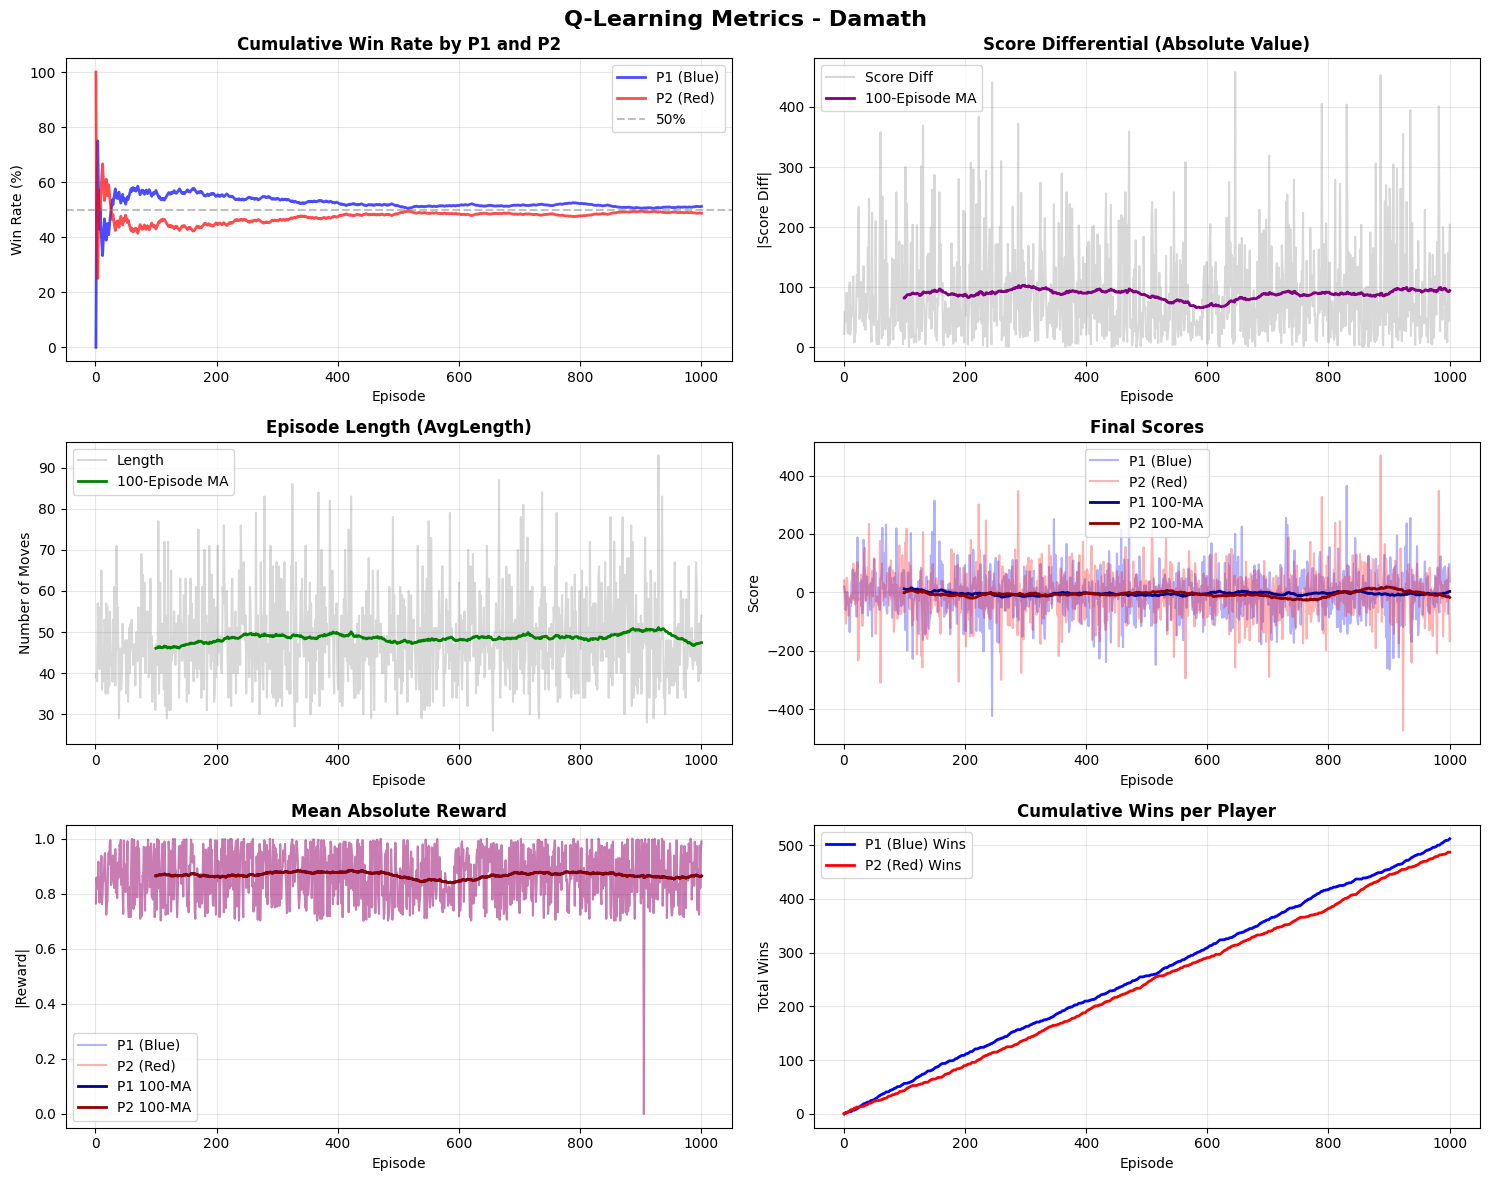

✅ Agent Q-table saved to 'damath_agent_high-eps.pkl'



In [115]:
if __name__ == "__main__":
    print("="*60)
    print("Q-LEARNING DAMATH TRAINING WITH COMPREHENSIVE METRICS")
    print("="*60)
    print("\nStarting Q-Learning training with self-play...")
    print("Agent plays as both Blue (Player 1) and Red (Player -1)\n")
    
    # Train the agent with metrics tracking
    trained_agent, training_metrics = train_qlearning_selfplay_with_metrics(
        episodes=1000,
        reward_alpha=0.7,
        learning_rate=0.01,
        gamma=0.9,
        epsilon=0.9,
        K=100.0
    )
    
    print("\n" + "="*60)
    print("TRAINING COMPLETED!")
    print("="*60)
    
    # Print comprehensive training summary
    training_metrics.print_summary()
    
    # Plot training metrics
    print("\nGenerating training metrics plots...")
    training_metrics.plot_metrics(window=100)
    
    # Save trained agent Q-table
    trained_agent.save('damath_agent_high-eps.pkl')
    print("✅ Agent Q-table saved to 'damath_agent_high-eps.pkl'\n")


In [116]:
def debug_qtable_states(agent, num_states=10):
    """
    Debug function to inspect the first N states in the Q-table.
    For each state, logs the available moves, their Q-values, and reconstructs the board.
    
    Args:
        agent: Trained QLearner agent with populated Q-table
        num_states: Number of states to inspect (default: 10)
    """
    print("="*80)
    print(f"Q-TABLE DEBUGGING: Inspecting first {num_states} states")
    print("="*80)
    
    if not agent.Q:
        print("⚠️  Q-table is empty!")
        return
    
    states_inspected = 0
    
    for state_key, actions_dict in agent.Q.items():
        if states_inspected >= num_states:
            break
        
        print(f"\n{'='*80}")
        print(f"STATE #{states_inspected + 1}")
        print(f"{'='*80}")
        
        # Unpack state information
        to_move, pieces_tuple = state_key
        player_str = "Blue (P1)" if to_move == 1 else "Red (P2)"
        print(f"Player to Move: {player_str}")
        print(f"Number of Pieces on Board: {len(pieces_tuple)}")
        
        # Reconstruct the board for visualization
        print("\nBoard State:")
        print("-" * 80)
        
        # Create a simple board representation
        board = [["  .  " for _ in range(8)] for _ in range(8)]
        
        # Place pieces
        for pos, player, value, is_dama in pieces_tuple:
            r, c = pos
            symbol = "🔵" if player == 1 else "🔴"
            dama_mark = "K" if is_dama else ""
            board[r][c] = f"{symbol}{dama_mark}{value:+2d}"
        
        # Print board from top to bottom
        print("     " + " ".join([f"  {x}  " for x in range(8)]))
        print("     " + "-----" * 8)
        for r in range(8):
            row_str = " ".join(board[r])
            print(f"  {r} | {row_str} | {r}")
        print("     " + "-----" * 8)
        print("     " + " ".join([f"  {x}  " for x in range(8)]))
        
        # Display Q-values for all actions in this state
        print(f"\n📊 Q-Values for Available Actions (Total: {len(actions_dict)}):")
        print("-" * 80)
        
        # Sort actions by Q-value (highest first)
        sorted_actions = sorted(actions_dict.items(), key=lambda x: x[1], reverse=True)
        
        for idx, (action_key, q_value) in enumerate(sorted_actions[:5], 1):  # Show top 5 actions
            path, captures = action_key
            
            # Format move description
            start = path[0]
            end = path[-1]
            move_desc = f"({start[1]},{start[0]}) → ({end[1]},{end[0]})"
            
            capture_desc = ""
            if captures:
                capture_desc = f" | Captures: {len(captures)}"
                capture_positions = ", ".join([f"({c},{r})" for r, c in captures])
                capture_desc += f" at [{capture_positions}]"
            
            print(f"  {idx}. Move: {move_desc}{capture_desc}")
            print(f"     Q-Value: {q_value:.6f}")
        
        if len(sorted_actions) > 5:
            print(f"  ... and {len(sorted_actions) - 5} more actions")
        
        # Show best action
        best_action, best_q = sorted_actions[0]
        best_path, best_captures = best_action
        print(f"\n⭐ BEST ACTION: ({best_path[0][1]},{best_path[0][0]}) → ({best_path[-1][1]},{best_path[-1][0]})")
        print(f"   Q-Value: {best_q:.6f}")
        if best_captures:
            print(f"   Captures {len(best_captures)} piece(s)")
        
        states_inspected += 1
    
    print(f"\n{'='*80}")
    print(f"✅ Inspected {states_inspected} states from Q-table")
    print(f"   Total states in Q-table: {len(agent.Q)}")
    print(f"   Total state-action pairs: {sum(len(actions) for actions in agent.Q.values())}")
    print("="*80)


# Example usage (uncomment to run after training):
debug_qtable_states(trained_agent, num_states=100)

Q-TABLE DEBUGGING: Inspecting first 100 states

STATE #1
Player to Move: Blue (P1)
Number of Pieces on Board: 17

Board State:
--------------------------------------------------------------------------------
       0     1     2     3     4     5     6     7  
     ----------------------------------------
  0 |   .   🔵-11   .   🔵+8   .     .     .   🔵+2 | 0
  1 | 🔵+0   .   🔵-3   .   🔵-5   .     .     .   | 1
  2 |   .   🔵-9   .   🔵+6   .     .     .   🔵-7 | 2
  3 |   .     .     .     .     .     .     .     .   | 3
  4 |   .   🔴+4   .   🔴+8   .     .     .     .   | 4
  5 |   .     .     .     .     .     .     .     .   | 5
  6 |   .   🔴-7   .   🔴+10   .     .     .   🔵+4 | 6
  7 | 🔴+2   .   🔴-5   .     .     .   🔴-11   .   | 7
     ----------------------------------------
       0     1     2     3     4     5     6     7  

📊 Q-Values for Available Actions (Total: 7):
--------------------------------------------------------------------------------
  1. Move: (7,0) → (6,1)
     Q-Va